# Experiment 2 – Multiple Linear Regression

Build a Multiple Linear Regression model to predict **CO2 emission** using **Volume and Weight** features.  
Perform correlation analysis, visualize relationships, detect outliers, train the model, and evaluate it using **MAE, MSE, and RMSE**.

First 5 rows:
   vehicle_id      make fuel_type  model_year    engine_cc  vehicle_weight  \
0           1      Ford    Petrol        2015  1723.557940     1584.733203   
1           2  Mercedes    Petrol        2010  1425.111578     1622.249986   
2           3      Audi    Hybrid        2011  1244.080888     1473.990569   
3           4       BMW    Petrol        2009  2177.834260     1831.274096   
4           5    Toyota    Petrol        2007  1848.899157     1732.637242   

   cylinders  annual_mileage_km  vehicle_age    co2_g_km  ...  co2_proxy_51  \
0          4       10529.056031           10  156.791111  ...    149.661615   
1          4       15779.243800           15  143.193198  ...    136.682017   
2          4       14129.167461           14  123.553651  ...    117.935506   
3          4        9290.136453           16  183.750695  ...    175.395312   
4          4       25519.247019           18  188.039024  ...    179.488644   

   co2_proxy_52  co2_proxy_53  co2_proxy_5

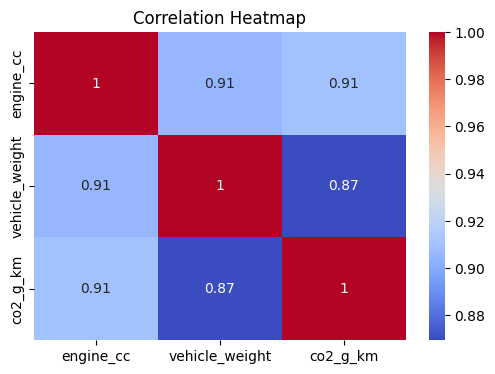

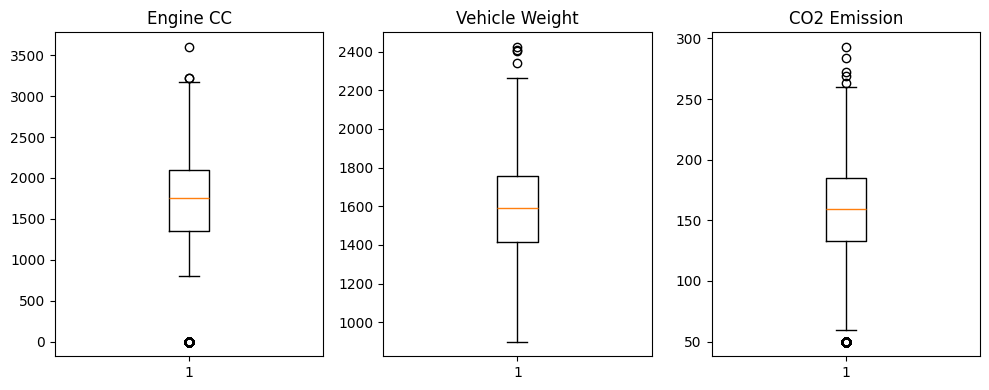

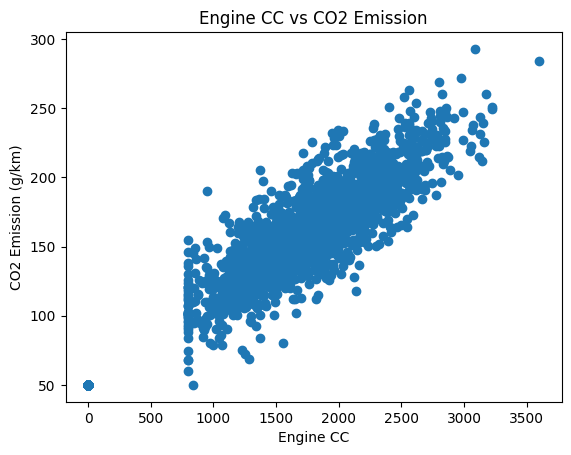

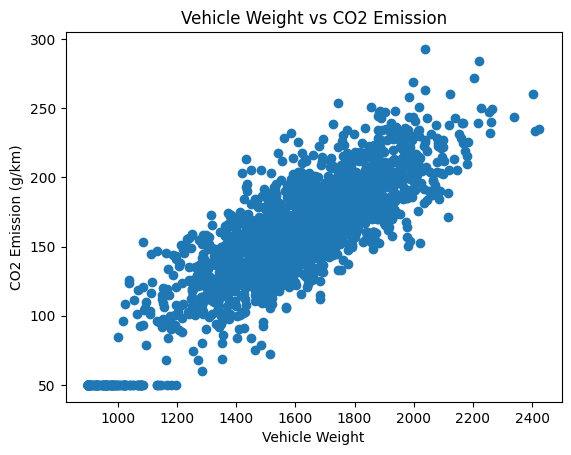


Model Coefficients:
Engine CC coefficient: 0.04656695435734197
Vehicle Weight coefficient: 0.03724529674036983
Intercept: 19.396135345551073


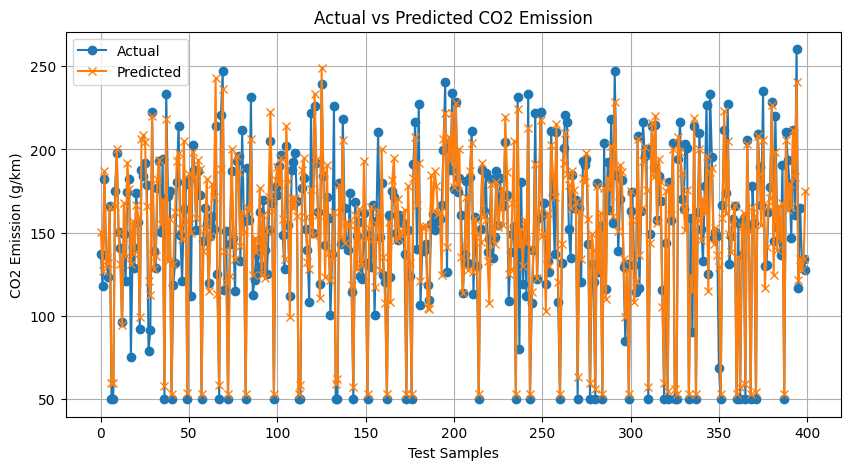


Error Metrics:
Mean Absolute Error (MAE): 13.04366265534356
Mean Squared Error (MSE): 300.41437526122735
Root Mean Squared Error (RMSE): 17.332465931344778


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error


# Load Dataset
df = pd.read_csv("co2_emission.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Information:")
df.info()

# Select Required Columns
data = df[["engine_cc", "vehicle_weight", "co2_g_km"]]

# Correlation Matrix & Heatmap
corr = data.corr()
print("\nCorrelation Matrix:")
print(corr)

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Boxplots (Outlier Detection)
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.boxplot(data["engine_cc"])
plt.title("Engine CC")

plt.subplot(1, 3, 2)
plt.boxplot(data["vehicle_weight"])
plt.title("Vehicle Weight")

plt.subplot(1, 3, 3)
plt.boxplot(data["co2_g_km"])
plt.title("CO2 Emission")

plt.tight_layout()
plt.show()

# Visualize Relationships
plt.scatter(data["engine_cc"], data["co2_g_km"])
plt.xlabel("Engine CC")
plt.ylabel("CO2 Emission (g/km)")
plt.title("Engine CC vs CO2 Emission")
plt.show()

plt.scatter(data["vehicle_weight"], data["co2_g_km"])
plt.xlabel("Vehicle Weight")
plt.ylabel("CO2 Emission (g/km)")
plt.title("Vehicle Weight vs CO2 Emission")
plt.show()

# Train-Test Split (80:20)
X = data[["engine_cc", "vehicle_weight"]]
y = data["co2_g_km"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Multiple Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Model Parameters
print("\nModel Coefficients:")
print("Engine CC coefficient:", model.coef_[0])
print("Vehicle Weight coefficient:", model.coef_[1])
print("Intercept:", model.intercept_)

# Predictions
y_pred = model.predict(X_test)

# True vs Predicted Plot
plt.figure(figsize=(10, 5))

plt.plot(y_test.values, label="Actual", marker='o')
plt.plot(y_pred, label="Predicted", marker='x')

plt.title("Actual vs Predicted CO2 Emission")
plt.xlabel("Test Samples")
plt.ylabel("CO2 Emission (g/km)")
plt.legend()
plt.grid(True)

plt.show()

# Error Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\nError Metrics:")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)